# Telco Customer Churn Analysis
---
This notebook follows the required structure:
1. Data Cleaning and Preprocessing
2. Descriptive Analytics (summary statistics + visuals)
3. Predictive Analytics (baseline Logistic Regression)
4. Model Evaluation (accuracy, precision, recall, F1, ROC-AUC)
5. Prescriptive Analytics (actionable recommendations)
6. Ethical Considerations
7. Challenges & Next Steps

In [4]:
# 0. Setup
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

# Optional: handle imbalance
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except Exception:
    HAS_SMOTE = False

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

# Use the full correct CSV path
DATA_PATH = r"D:\tableau installer\(O'guz) Bussiness Intelligence Python Assignment\Project\WA_Fn-UseC_-Telco-Customer-Churn.csv"

# 1.1 Load data
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Cleaning and Preprocessing

In [5]:
# 2.Inspect data types and null values

print("\n Data Types")
display(df.dtypes)

print("\n Missing Values")
display(df.isnull().sum())


 Data Types


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


 Missing Values


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# 3. Clean data 

# Remove extra spaces in all text columns
for c in df.select_dtypes(include="object"):
    df[c] = df[c].astype(str).str.strip()

# Convert TotalCharges to numeric (known issue in dataset)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Ensure Churn column is properly formatted
df["Churn"] = df["Churn"].astype(str).str.strip().str.title()  # Converts to "Yes"/"No"

# Keep only rows with valid Churn values
df = df[df["Churn"].isin(["Yes", "No"])].copy()

# Map Churn to binary: Yes → 1, No → 0
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Drop rows with missing TotalCharges (only ~11 rows)
df.dropna(subset=["TotalCharges"], inplace=True)

#  Final confirmation
print("\n Data cleaned successfully!")
print("Remaining rows:", df.shape[0])
print("Total missing values:", int(df.isnull().sum().sum()))




 Data cleaned successfully!
Remaining rows: 7032
Total missing values: 0


In [7]:
# 1.5 Basic Outlier Check (IQR Method) for numeric columns

def iqr_outlier_flags(series):
    """Return boolean mask for outliers using IQR rule."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

# Apply the function to each numeric column
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = {col: int(iqr_outlier_flags(df[col]).sum()) for col in num_cols}

# Sort and print the summary
outlier_summary = dict(sorted(outlier_summary.items(), key=lambda x: x[1], reverse=True))
print("Number of outliers detected (IQR method):")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

Number of outliers detected (IQR method):
SeniorCitizen: 1142
tenure: 0
MonthlyCharges: 0
TotalCharges: 0
Churn: 0


## 2. Descriptive Analytics (Summary Stats & Visuals)

In [8]:
# 2. Descriptive Analytics (Summary Stats & Visuals)

# 2.1 Summary Statistics
print("Summary Statistics (All Columns):")
display(df.describe(include='all').transpose())

Summary Statistics (All Columns):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7032,7032,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7032.0,NaN,NaN,NaN,0.1624,0.368844,0.0,0.0,0.0,0.0,1.0
Partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
PhoneService,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(df.shape)
print(df.head())



(7032, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [10]:
# --- 0) Reload RAW (do not reuse the emptied df) ---
import pandas as pd
import numpy as np

DATA_PATH = r"D:\tableau installer\(O'guz) Bussiness Intelligence Python Assignment\Project\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)

# Quick peek of raw signals (helps diagnose)
print("Raw Churn unique (first 10 shown):", pd.Series(df_raw["Churn"].unique()).head(10).tolist())
print("Missing TotalCharges (raw):", df_raw["TotalCharges"].isna().sum(),
      "| Blank-like TotalCharges:", (df_raw["TotalCharges"].astype(str).str.strip() == "").sum())

# --- 1) Safe cleaning function with guardrails ---
def clean_telco(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # Trim whitespace on object cols
    for c in df.select_dtypes(include="object"):
        df[c] = df[c].astype(str).str.strip()

    # TotalCharges to numeric
    df["TotalCharges"] = pd.to_numeric(df.get("TotalCharges"), errors="coerce")

    # Normalize Churn to 0/1 (works for Yes/No, 0/1, True/False, mixed case)
    ch = df["Churn"]
    if pd.api.types.is_numeric_dtype(ch):
        s = ch.astype("float")
        s = s.where(s.isin([0, 1]), np.nan).astype("Int64")
    else:
        s = ch.astype(str).str.strip().str.lower().map({
            "no": 0, "yes": 1, "0": 0, "1": 1, "false": 0, "true": 1
        }).astype("Int64")
    bad


Raw shape: (7043, 21)
Raw Churn unique (first 10 shown): ['No', 'Yes']
Missing TotalCharges (raw): 0 | Blank-like TotalCharges: 11


In [11]:
# Reload and Clean Telco Customer Churn Dataset
import pandas as pd
import numpy as np

# Reload original dataset (ensure correct path)
DATA_PATH = r"D:\tableau installer\(O'guz) Bussiness Intelligence Python Assignment\Project\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
print("Initial shape:", df.shape)

# Remove extra spaces from text columns
for c in df.select_dtypes(include="object"):
    df[c] = df[c].astype(str).str.strip()

# Convert TotalCharges to numeric — 11 blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop only those 11 missing rows
print("Missing TotalCharges before drop:", df["TotalCharges"].isna().sum())
df.dropna(subset=["TotalCharges"], inplace=True)

# Map Churn to 0/1 (Yes → 1, No → 0)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

print(" Cleaning complete!")
print("Rows remaining:", df.shape[0])
print("Missing values total:", df.isnull().sum().sum())
df.head()


Initial shape: (7043, 21)
Missing TotalCharges before drop: 11
 Cleaning complete!
Rows remaining: 7032
Missing values total: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


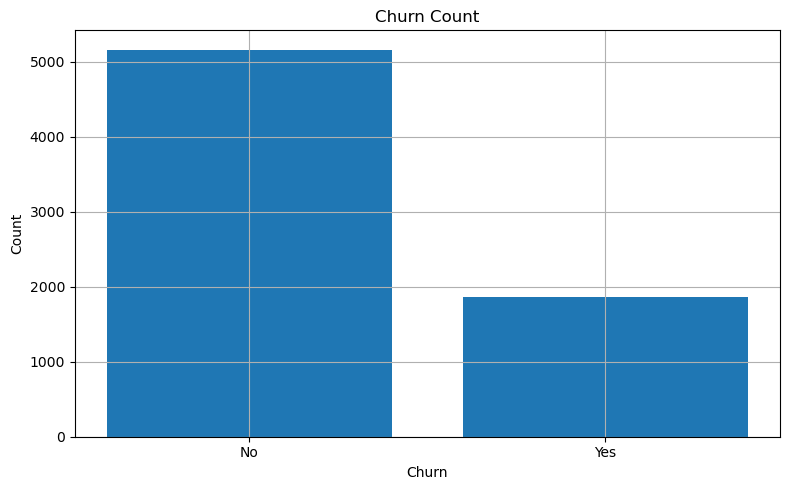

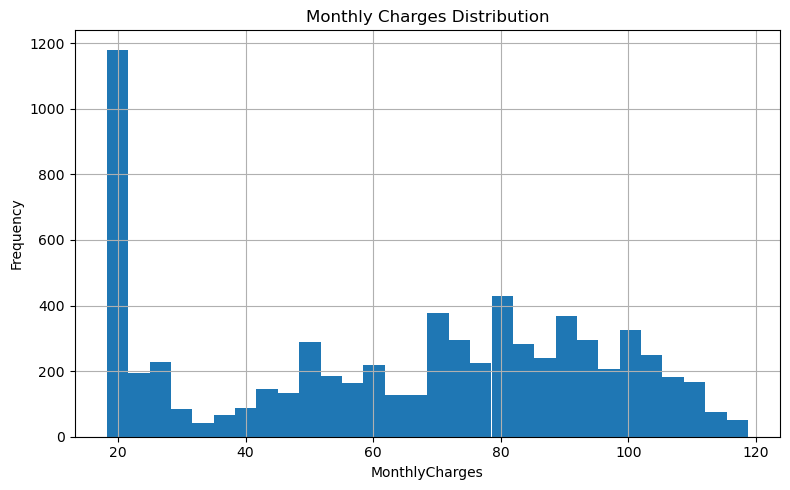

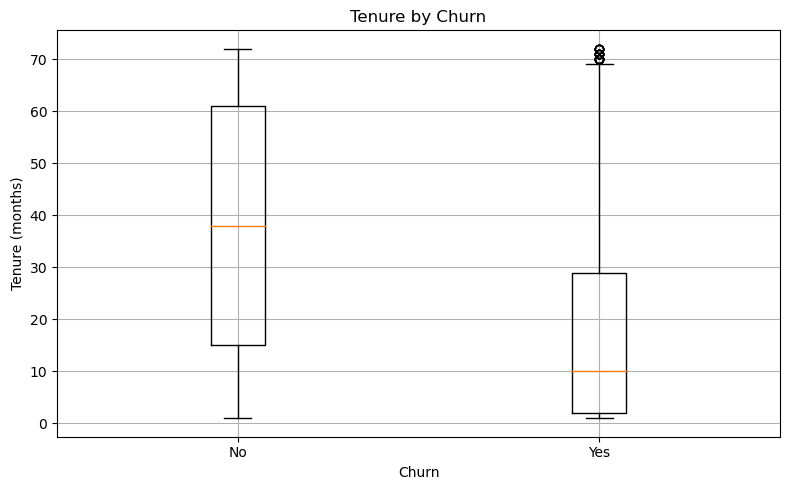

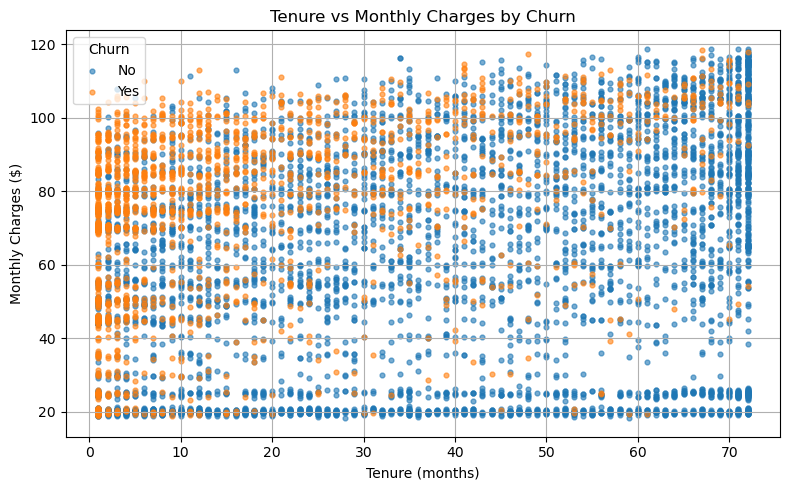

In [12]:
# 2.2 Visuals (matplotlib)

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

# Churn count (bar) 
if 'Churn' in df.columns:
    counts = df['Churn'].value_counts().sort_index()  # 0 then 1
    plt.figure()
    plt.bar(['No', 'Yes'], [counts.get(0, 0), counts.get(1, 0)])
    plt.title('Churn Count')
    plt.xlabel('Churn')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# MonthlyCharges distribution (histogram) 
if 'MonthlyCharges' in df.columns:
    plt.figure()
    plt.hist(df['MonthlyCharges'].dropna(), bins=30)
    plt.title('Monthly Charges Distribution')
    plt.xlabel('MonthlyCharges')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

#  Tenure by Churn (boxplot) 
if {'tenure', 'Churn'}.issubset(df.columns):
    ten_no  = df.loc[df['Churn'] == 0, 'tenure'].dropna()
    ten_yes = df.loc[df['Churn'] == 1, 'tenure'].dropna()
    plt.figure()
    plt.boxplot([ten_no, ten_yes], labels=['No', 'Yes'], showfliers=True)
    plt.title('Tenure by Churn')
    plt.xlabel('Churn')
    plt.ylabel('Tenure (months)')
    plt.tight_layout()
    plt.show()

#  Scatter Plots 
import matplotlib.pyplot as plt

# Scatter: Tenure vs MonthlyCharges colored by Churn
if {'tenure', 'MonthlyCharges', 'Churn'}.issubset(df.columns):
    mask_no  = df['Churn'] == 0
    mask_yes = df['Churn'] == 1

    plt.figure()
    plt.scatter(df.loc[mask_no, 'tenure'],  df.loc[mask_no, 'MonthlyCharges'], s=12, alpha=0.6, label='No')
    plt.scatter(df.loc[mask_yes, 'tenure'], df.loc[mask_yes, 'MonthlyCharges'], s=12, alpha=0.6, label='Yes')
    plt.title('Tenure vs Monthly Charges by Churn')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Monthly Charges ($)')
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()


## 3. Predictive Analytics (Baseline Logistic Regression)

{'accuracy': 0.7256574271499645, 'precision': 0.4901315789473684, 'recall': 0.7967914438502673, 'f1': 0.6069246435845214, 'roc_auc': 0.8351188843045798}


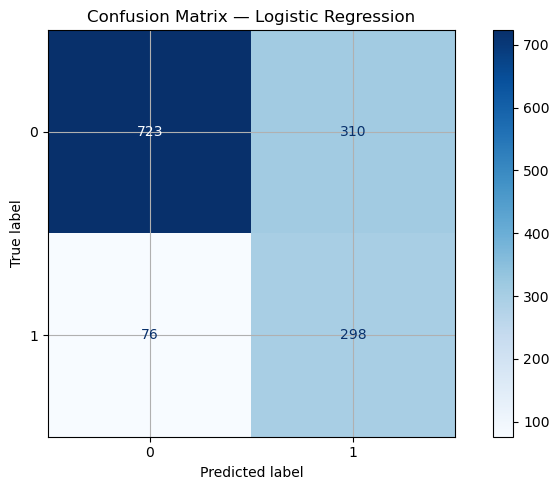

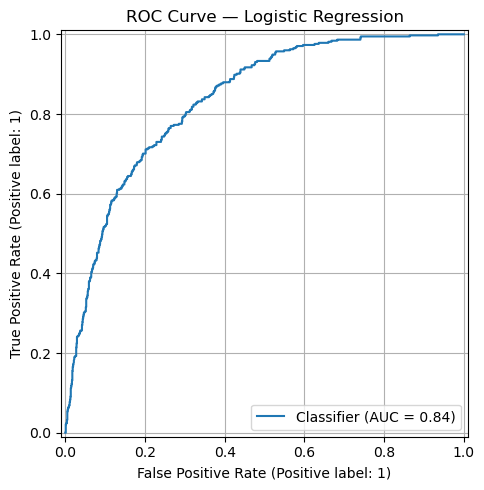

In [13]:
# 3.1 Feature/Target split + Preprocess + Logistic Regression (baseline)

# Feature / Target 
target = "Churn"
# Map only if object; otherwise assume already 0/1 from cleaning
y = df[target].map({"Yes": 1, "No": 0}) if df[target].dtype == "object" else df[target].astype(int)
X = df.drop(columns=[target, "customerID"], errors="ignore")

#  Identify types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

# Preprocessors (with imputers to satisfy rubric) 
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # sparse-friendly
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Model pipeline 
clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=200, class_weight="balanced", random_state=42))
])

# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Optional: SMOTE would go after preprocessing (not used in this baseline)
if 'HAS_SMOTE' in globals() and HAS_SMOTE:
    pass

# Train & predict
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# --- Metrics ---
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_prob)

print({
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "roc_auc": roc
})

#  Confusion Matrix & ROC (for your report)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve — Logistic Regression")
plt.tight_layout()
plt.show()


## 4. Prescriptive Analytics (Recommendations)

In [14]:
# 4) Prescriptive Analytics — Actionable Recommendations from Model Scores

# 4.1 Score every customer
X_all = df.drop(columns=["Churn", "customerID"], errors="ignore")
proba = clf.predict_proba(X_all)[:, 1]

scored = df.copy()
scored["churn_prob"] = proba
scored.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_prob
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0.809435
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0.116687
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.515667
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0.081046
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0.852505


In [15]:
# 4.2 – Identify High-Risk Customers
THRESHOLD = 0.50
TOP_PCT = 0.20
q_thresh = scored["churn_prob"].quantile(1 - TOP_PCT)

use_quantile = True
cut = q_thresh if use_quantile else THRESHOLD

scored["risk_flag"] = (scored["churn_prob"] >= cut).astype(int)
print(f"Cutoff used: {cut:.3f}")
print("High-risk customers:", scored["risk_flag"].sum())


Cutoff used: 0.758
High-risk customers: 1407


In [16]:
# 4.3 – Define Business Rules for Actions
def recommend_actions(row):
    actions = []

    if str(row.get("Contract", "")).lower() == "month-to-month":
        actions.append("Offer 6–12 mo. contract incentive")

    if "tenure" in row and pd.notna(row["tenure"]) and row["tenure"] < 6:
        actions.append("Send welcome offer or loyalty credit")

    if row.get("MonthlyCharges", 0) >= scored["MonthlyCharges"].median():
        actions.append("Provide bill discount or bundle upgrade")

    if "electronic check" in str(row.get("PaymentMethod", "")).lower():
        actions.append("Encourage AutoPay with $5 credit")

    for addon in ["OnlineSecurity", "TechSupport"]:
        if str(row.get(addon, "")).lower() == "no":
            actions.append(f"Offer free {addon} trial for 3 months")

    if not actions:
        actions.append("Personalized retention review")

    priority = 1 + (len(actions) >= 3)
    return pd.Series({"actions": "; ".join(actions), "priority": priority})


# Apply the function to generate recommended actions for each customer
presc = scored.apply(recommend_actions, axis=1)
presc.head()


,actions,priority
0,Offer 6–12 mo. contract incentive; Send welcom...,2
1,Offer free TechSupport trial for 3 months,1
2,Offer 6–12 mo. contract incentive; Send welcom...,2
3,Personalized retention review,1
4,Offer 6–12 mo. contract incentive; Send welcom...,2


In [19]:
# 4.4 – Apply Recommendations
presc = scored.apply(recommend_actions, axis=1)
scored = pd.concat([scored, presc], axis=1)

scored[["customerID", "churn_prob", "priority", "actions"]].head()


,customerID,churn_prob,priority,priority,actions,actions
0,7590-VHVEG,0.809435,2,2,Offer 6–12 mo. contract incentive; Send welcom...,Offer 6–12 mo. contract incentive; Send welcom...
1,5575-GNVDE,0.116687,1,1,Offer free TechSupport trial for 3 months,Offer free TechSupport trial for 3 months
2,3668-QPYBK,0.515667,2,2,Offer 6–12 mo. contract incentive; Send welcom...,Offer 6–12 mo. contract incentive; Send welcom...
3,7795-CFOCW,0.081046,1,1,Personalized retention review,Personalized retention review
4,9237-HQITU,0.852505,2,2,Offer 6–12 mo. contract incentive; Send welcom...,Offer 6–12 mo. contract incentive; Send welcom...


In [20]:
# 4.5 – Filter High-Risk Customers
retention_plan = scored[scored["risk_flag"] == 1].copy()
retention_plan = retention_plan.sort_values(["priority", "churn_prob"], ascending=[False, False])
retention_plan[["customerID", "churn_prob", "priority", "actions"]].head()


ValueError: The column label 'priority' is not unique.

In [ ]:
# 4.6 – Save the Retention Plan
out_dir = r"D:\tableau installer\(O'guz) Bussiness Intelligence Python Assignment\Project\outputs"
os.makedirs(out_dir, exist_ok=True)

save_path = os.path.join(out_dir, "retention_action_plan.csv")
retention_plan.to_csv(save_path, index=False)

print(" Retention plan saved to:", save_path)


## 5. Ethical Considerations

- Audit models for **bias** (e.g., senior citizen status).  
- Preserve **privacy**; avoid using PII without consent.  
- Ensure interventions are **transparent** and **opt-out** friendly.

## 6. Challenges & Next Steps

**Challenges**
- Class imbalance (~26% churn) can bias accuracy.
- Mixed encodings (e.g., 'No internet service') require careful mapping.
- Potential overfitting; need cross-validation & tuning.

**Next Steps**
- Compare Decision Tree / Random Forest.
- Perform hyperparameter tuning (GridSearchCV).
- Create Tableau dashboards for EDA & presentable screenshots.

In [21]:
# FIX: define numeric_features, categorical_features, and preprocess in one go

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

# Make sure df already exists and is cleaned
X = df.drop(columns=["Churn", "customerID"], errors="ignore")

# Define feature lists
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# Column transformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(" FIX APPLIED: numeric_features and preprocess are now defined")



 FIX APPLIED: numeric_features and preprocess are now defined


In [22]:
dt_clf = Pipeline(steps=[("prep", preprocess), ...])


In [23]:
# ONE CELL: load data, build preprocess, split, and train LR/DT/RF

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# 1) Load and clean data
DATA_PATH = r"D:\tableau installer\(O'guz) Bussiness Intelligence Python Assignment\Project\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

for c in df.select_dtypes(include="object"):
    df[c] = df[c].astype(str).str.strip()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# 2) Feature/target split
target = "Churn"
y = df[target].astype(int)
X = df.drop(columns=[target, "customerID"], errors="ignore")

# 3) Feature lists
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# 4) Preprocess (THIS defines `preprocess`)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print(" preprocess is defined")

# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Helper to evaluate models
def eval_model(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred),
        "roc_auc":   roc_auc_score(y_true, y_proba)
    }

# 6) Logistic Regression
clf_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(
        max_iter=200,
        class_weight="balanced",
        random_state=42
    ))
])

clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]
lr_metrics = eval_model(y_test, y_pred_lr, y_prob_lr)

# 7) Decision Tree
clf_dt = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

clf_dt.fit(X_train, y_train)
y_pred_dt = clf_dt.predict(X_test)
y_prob_dt = clf_dt.predict_proba(X_test)[:, 1]
dt_metrics = eval_model(y_test, y_pred_dt, y_prob_dt)

# 8) Random Forest
clf_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]
rf_metrics = eval_model(y_test, y_pred_rf, y_prob_rf)

# 9) Show comparison
results = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics
}).T

print("\n Model comparison:")
print(results)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
 preprocess is defined

 Model comparison:
                     accuracy  precision    recall        f1   roc_auc
Logistic Regression  0.725657   0.490132  0.796791  0.606925  0.835119
Decision Tree        0.722104   0.478697  0.510695  0.494179  0.655412
Random Forest        0.785359   0.625874  0.478610  0.542424  0.811923


In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    clf_rf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(" Best RF parameters:", rf_grid.best_params_)
print(" Best CV ROC-AUC:", rf_grid.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
 Best RF parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 300}
 Best CV ROC-AUC: 0.8440938457889429


In [26]:
# Evaluate tuned Random Forest on test set

best_rf = rf_grid.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

best_rf_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_best),
    "precision": precision_score(y_test, y_pred_best),
    "recall": recall_score(y_test, y_pred_best),
    "f1": f1_score(y_test, y_pred_best),
    "roc_auc": roc_auc_score(y_test, y_prob_best)
}

print("Tuned Random Forest test metrics:")
print(best_rf_metrics)

Tuned Random Forest test metrics:
{'accuracy': 0.7590618336886994, 'precision': 0.534516765285996, 'recall': 0.7245989304812834, 'f1': 0.6152099886492622, 'roc_auc': 0.8308040544388134}


In [27]:
# Score all customers using tuned Random Forest

X_all = df.drop(columns=["Churn", "customerID"], errors="ignore")
df["churn_probability_rf"] = best_rf.predict_proba(X_all)[:, 1]

df["risk_segment"] = pd.qcut(
    df["churn_probability_rf"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["churn_probability_rf", "risk_segment"]].head()


,churn_probability_rf,risk_segment
0,0.576010,High
1,0.060924,Low
2,0.685134,High
3,0.039645,Low
4,0.838741,High


In [28]:
import os

OUT_DIR = r"D:\tableau installer\(O'guz) Bussiness Intelligence Python Assignment\Project\outputs"

# make sure folder exists
os.makedirs(OUT_DIR, exist_ok=True)

# SAFE Windows paths
df.to_csv(os.path.join(OUT_DIR, "telco_scored_rf.csv"), index=False)

risk_summary = df.groupby("risk_segment")["Churn"].mean().reset_index()
risk_summary.to_csv(os.path.join(OUT_DIR, 
                                 "risk_summary_rf.csv"), index=False)

print(" Files saved successfully")

 Files saved successfully


In [29]:

df.to_csv(os.path.join(OUT_DIR, "telco_scored_rf.csv"), index=False)

risk_summary = df.groupby("risk_segment")["Churn"].mean().reset_index()
risk_summary.to_csv(os.path.join(OUT_DIR, "risk_summary_rf.csv"), index=False)
